# PASO 1. Instalar las librerías

In [ ]:
!pip install -q transformers datasets accelerate scikit-learn

# PASO 2. Importar librerías y comprobar la GPU

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    pipeline,
    set_seed
)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
set_seed(RANDOM_STATE)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "Memoria GPU:",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / 1024**3,
            2
        ),
        "GB"
    )

CUDA disponible: True
GPU: Tesla T4
Memoria GPU: 14.56 GB


In [ ]:
# settings adicionales para el display
pd.set_option("display.max_colwidth", None)

# PASO 3. Preparar datos

En esta parte:
- Leemos el dataset original
- Visualizamos los distintos productos a clasificar
- Filtramos el Dataset para quedarnos exclusivamente con las columnas que nos interesan: Producto + Queja
- Ajustamos aquellas categorías de producto que consideramos parecidas o agrupables para facilitar este primer approach de clasificación

In [ ]:
df = pd.read_csv("/data/complaints.csv")

In [ ]:
df["Product"].unique()

array(['Mortgage',
       'Credit reporting, credit repair services, or other personal consumer reports',
       'Debt collection', 'Checking or savings account',
       'Credit card or prepaid card',
       'Payday loan, title loan, or personal loan',
       'Vehicle loan or lease',
       'Money transfer, virtual currency, or money service',
       'Student loan',
       'Credit reporting or other personal consumer reports',
       'Payday loan, title loan, personal loan, or advance loan',
       'Credit card', 'Debt or credit management', 'Prepaid card'],
      dtype=object)

In [ ]:
df_filtered = df[["Product", "Consumer complaint narrative"]]

In [ ]:
TEXT_COL = "Consumer complaint narrative"
ORIGINAL_LABEL_COL = "Product"
FAMILY_LABEL_COL = "Product_family"
# Mapeo del producto original a la nueva agrupación por familias creada
PRODUCT_FAMILY_MAP = {
    "Mortgage":
        "Mortgage",

    "Checking or savings account":
        "Checking or savings account",

    "Vehicle loan or lease":
        "Vehicle loan or lease",

    "Money transfer, virtual currency, or money service":
        "Money transfer, virtual currency, or money service",

    "Student loan":
        "Student loan",

    # Agrupación 1: credit reporting
    "Credit reporting, credit repair services, or other personal consumer reports":
        "Credit reporting",

    "Credit reporting or other personal consumer reports":
        "Credit reporting",

    # Agrupación 2: tarjetas
    "Credit card or prepaid card":
        "Credit or prepaid card",

    "Credit card":
        "Credit or prepaid card",

    "Prepaid card":
        "Credit or prepaid card",

    # Agrupación 3: présamos personales
    "Payday loan, title loan, or personal loan":
        "Payday, title, personal or advance loan",

    "Payday loan, title loan, personal loan, or advance loan":
        "Payday, title, personal or advance loan",

    # Agrupación 4: deuda
    "Debt collection":
        "Debt collection or management",

    "Debt or credit management":
        "Debt collection or management",
}

data_bert = df_filtered[
    [ORIGINAL_LABEL_COL, TEXT_COL]
].copy()


# Eliminamos aquellas filas en las cuales nos faltan valores ya que tenemos suficientes registros
data_bert = data_bert.dropna(
    subset=[ORIGINAL_LABEL_COL, TEXT_COL]
).copy()

data_bert = data_bert[
    data_bert[TEXT_COL]
    .astype(str)
    .str.strip()
    .ne("")
].copy()

# Aplicamos los mapeos para crear la agrupación por familias
data_bert[FAMILY_LABEL_COL] = (
    data_bert[ORIGINAL_LABEL_COL]
    .map(PRODUCT_FAMILY_MAP)
)

# Comprobaciones
missing_products = (
    data_bert.loc[
        data_bert[FAMILY_LABEL_COL].isna(),
        ORIGINAL_LABEL_COL
    ]
    .drop_duplicates()
    .tolist()
)

if missing_products:
    raise ValueError(
        "Hay productos sin agrupar: "
        f"{missing_products}"
    )

# Dataset final:
data_bert = data_bert[
    [FAMILY_LABEL_COL, TEXT_COL]
].reset_index(drop=True)


print("Número de observaciones:", len(data_bert))
display(
    data_bert[FAMILY_LABEL_COL]
    .value_counts()
    .rename("n_observations")
    .to_frame()
)

Número de observaciones: 582490


,n_observations
Product_family,
Credit reporting,421477
Debt collection or management,50593
Credit or prepaid card,41686
Checking or savings account,27243
Mortgage,12064
"Money transfer, virtual currency, or money service",9061
Student loan,8464
Vehicle loan or lease,7219
"Payday, title, personal or advance loan",4683


A diferencia del enfoque regex, aquí no limpiamos mucho el texto. BERT utiliza el contexto y su propio tokenizador, por lo que no queremos eliminar información que pueda ser útil

### Distribución de las categorías

El dataset final contiene 582.490 reclamaciones agrupadas en nueve familias de producto. La distribución está fuertemente desbalanceada: `Credit reporting` representa aproximadamente el 72,4 % de los registros, mientras que categorías como `Payday, title, personal or advance loan`, `Vehicle loan or lease` y `Student loan` representan individualmente menos del 1,5 %.

Este desbalanceo hace que la accuracy global pueda estar dominada por la categoría mayoritaria. Por ello, la evaluación incluirá también macro F1 y métricas por producto. Adicionalmente, balanceamos el dataset

# PASO 4. Convertir las categorías en números

El modelo no trabaja directamente con nombres como Mortgage o Student loan. Necesita que cada familia tenga un identificador numérico.

Guardamos también la relación inversa para poder convertir después la predicción numérica en un nombre comprensible

In [ ]:
# Ordenamos familias y les asignamos un número a cada una
label_names = sorted(
    data_bert[FAMILY_LABEL_COL].unique()
)

label2id = {
    label: idx
    for idx, label in enumerate(label_names)
}

id2label = {
    idx: label
    for label, idx in label2id.items()
}

data_bert["labels"] = (
    data_bert[FAMILY_LABEL_COL]
    .map(label2id)
)

print("Relación entre etiquetas y números:")

for label, label_id in label2id.items():
    print(f"{label_id}: {label}")

Relación entre etiquetas y números:
0: Checking or savings account
1: Credit or prepaid card
2: Credit reporting
3: Debt collection or management
4: Money transfer, virtual currency, or money service
5: Mortgage
6: Payday, title, personal or advance loan
7: Student loan
8: Vehicle loan or lease


### Codificación de las etiquetas

Las nueve familias se codifican con identificadores numéricos entre 0 y 8, necesarios para entrenar el modelo. Esta transformación es únicamente técnica y no modifica el significado ni la distribución de las categorías.

# PASO 5. Dividir los datos en entrenamiento, validación y test

In [ ]:
train_df, temp_df = train_test_split(
    data_bert,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=data_bert["labels"]
)

validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_df["labels"]
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


print("Observaciones de train:     ", len(train_df))
print("Observaciones de validación:", len(validation_df))
print("Observaciones de test:      ", len(test_df))

Observaciones de train:      465992
Observaciones de validación: 58249
Observaciones de test:       58249


### División de los datos

Los datos se dividen de forma estratificada en un 80 % para entrenamiento, un 10 % para validación y un 10 % para test:

- Train: 465.992 observaciones.
- Validation: 58.249 observaciones.
- Test: 58.249 observaciones.

Validation se utiliza para seleccionar decisiones como el threshold de confianza, mientras que test se reserva para la evaluación final.

Comprobamos que los tres conjuntos mantienen una distribución parecida

In [ ]:
distribution_comparison = pd.concat(
    [
        train_df[FAMILY_LABEL_COL]
        .value_counts(normalize=True)
        .rename("train"),

        validation_df[FAMILY_LABEL_COL]
        .value_counts(normalize=True)
        .rename("validation"),

        test_df[FAMILY_LABEL_COL]
        .value_counts(normalize=True)
        .rename("test")
    ],
    axis=1
).fillna(0)


display(distribution_comparison)

,train,validation,test
Product_family,,,
Credit reporting,0.723579,0.723583,0.723566
Debt collection or management,0.086856,0.086851,0.086868
Credit or prepaid card,0.071566,0.071572,0.071555
Checking or savings account,0.046771,0.046765,0.046765
Mortgage,0.020711,0.020704,0.020721
"Money transfer, virtual currency, or money service",0.015556,0.015554,0.015554
Student loan,0.014530,0.014541,0.014524
Vehicle loan or lease,0.012393,0.012395,0.012395
"Payday, title, personal or advance loan",0.008039,0.008034,0.008052


### Consistencia de las distribuciones

La estratificación mantiene prácticamente idéntica la proporción de cada producto en train, validation y test. Por ejemplo, `Credit reporting` representa alrededor del 72,36 % en los tres conjuntos.

Esto permite comparar los resultados entre particiones y garantiza que validation y test reproducen el desbalanceo observado en los datos originales.

# PASO 6. Muestra de Train

En vez de tomar una muestra aleatoria (que mantendría el desequilibrio original), limitamos el número máximo de observaciones por categoría.

No hacemos que todas tengan exactamente el mismo tamaño:

Las clases pequeñas mantienen todos sus registros.
Las clases grandes se reducen.
Ninguna clase puede aportar más de MAX_SAMPLES_PER_CLASS.

Así evitamos que Credit reporting domine casi todo el entrenamiento, y nos de métricas globales infladas.

Esto lo hacemos sólo en train

In [ ]:
MAX_SAMPLES_PER_CLASS = 20_000


def create_balanced_train_sample(
    dataframe,
    label_col,
    max_samples_per_class,
    random_state=42
):
    """
    Reduce las categorías más grandes y conserva todos los
    registros disponibles de las categorías pequeñas.

    """

    sampled_groups = []

    for label, group in dataframe.groupby(label_col):

        # Si la categoría tiene más registros que el máximo, cogemos una muestra aleatoria.
        if len(group) > max_samples_per_class:
            sampled_group = group.sample(
                n=max_samples_per_class,
                random_state=random_state
            )

        # Si tiene menos, nos quedamos con todos sus registros.
        else:
            sampled_group = group.copy()

        sampled_groups.append(sampled_group)

    # Unimos todas las categorías
    balanced_dataframe = pd.concat(
        sampled_groups,
        ignore_index=True
    )

    # Mezclamos las filas para que no estén ordenadas por categoría
    balanced_dataframe = balanced_dataframe.sample(
        frac=1,
        random_state=random_state
    ).reset_index(drop=True)

    return balanced_dataframe

In [ ]:
train_model_df = create_balanced_train_sample(
    dataframe=train_df,
    label_col="labels",
    max_samples_per_class=MAX_SAMPLES_PER_CLASS,
    random_state=RANDOM_STATE
)


print(
    "Observaciones utilizadas para entrenar:",
    len(train_model_df)
)


display(
    train_model_df[FAMILY_LABEL_COL]
    .value_counts()
    .rename("n_train")
    .to_frame()
)

Observaciones utilizadas para entrenar: 113192


,n_train
Product_family,
Checking or savings account,20000
Debt collection or management,20000
Credit or prepaid card,20000
Credit reporting,20000
Mortgage,9651
"Money transfer, virtual currency, or money service",7249
Student loan,6771
Vehicle loan or lease,5775
"Payday, title, personal or advance loan",3746


### Efecto del balanceo

Para el entrenamiento se limita cada categoría a un máximo de 20.000 observaciones, reduciendo la muestra de train de 465.992 a 113.192 registros.

Las cuatro categorías más frecuentes quedan limitadas a 20.000 ejemplos, mientras que las categorías minoritarias conservan todas sus observaciones. De esta forma se reduce el dominio de `Credit reporting` sin perder información de las clases menos representadas.

El balanceo se aplica únicamente a train. Validation y test mantienen la distribución original para evaluar el modelo en condiciones realistas.

# PASO 7. Cargar SEC-BERT y su tokenizador

El tokenizador transforma el texto en números que BERT puede procesar. SEC-BERT utiliza un vocabulario propio de unas 30.000 unidades o subwords, aprendido a partir de documentación financiera. El modelo admite secuencias de hasta 512 tokens.

Utilizaremos una longitud máxima de 128 tokens para reducir el coste computacional:

Las quejas más cortas conservan su longitud real.
Las quejas de más de 128 tokens se recortan.
El padding se añadirá más adelante, dinámicamente.

In [ ]:
MODEL_NAME = "nlpaueb/sec-bert-base"
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    label2id=label2id,
    id2label=id2label
)

print("Modelo:", MODEL_NAME)
print("Número de categorías:", len(label_names))
print("Longitud máxima utilizada:", MAX_LENGTH)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: nlpaueb/sec-bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params wer

Modelo: nlpaueb/sec-bert-base
Número de categorías: 9
Longitud máxima utilizada: 128


### Inicialización del modelo

SEC-BERT aporta una representación del lenguaje previamente entrenada sobre textos financieros. Sin embargo, su capa final de clasificación se inicializa desde cero porque debe aprender las nueve categorías específicas de este problema.

Durante el fine-tuning se ajustan tanto esta nueva capa como los pesos del modelo al contenido de las reclamaciones.

Es normal que aparezca un aviso indicando que algunos pesos de la capa de clasificación son nuevos. SEC-BERT conoce lenguaje financiero, pero nunca había sido entrenado para predecir nuestras nueve familias. Esa capa se aprenderá durante el entrenamiento

# PASO 8. Convertir los pandas DataFrames en Hugging Face Datasets

Trainer trabaja cómodamente con objetos de tipo Dataset. Solo necesitamos mantener el texto y la etiqueta numérica.

In [ ]:
train_dataset = Dataset.from_pandas(
    train_model_df[
        [TEXT_COL, "labels"]
    ],
    preserve_index=False
)


validation_dataset = Dataset.from_pandas(
    validation_df[
        [TEXT_COL, "labels"]
    ],
    preserve_index=False
)


test_dataset = Dataset.from_pandas(
    test_df[
        [TEXT_COL, "labels"]
    ],
    preserve_index=False
)


print("Train:")
print(train_dataset)

print("\nValidación:")
print(validation_dataset)

print("\nTest:")
print(test_dataset)

Train:
Dataset({
    features: ['Consumer complaint narrative', 'labels'],
    num_rows: 113192
})

Validación:
Dataset({
    features: ['Consumer complaint narrative', 'labels'],
    num_rows: 58249
})

Test:
Dataset({
    features: ['Consumer complaint narrative', 'labels'],
    num_rows: 58249
})


### Longitud de entrada

Las reclamaciones se tokenizan con una longitud máxima de 128 tokens. Las más largas se truncan y las más cortas se completan dinámicamente dentro de cada batch.

Este límite reduce el consumo de memoria y el tiempo de entrenamiento, aunque puede provocar pérdida de información en reclamaciones extensas. Con mayor capacidad de cómputo sería recomendable evaluar longitudes superiores y medir su impacto sobre el rendimiento.

# PASO 9. Tokenizar las quejas

Tokenizar significa dividir el texto en las unidades que entiende SEC-BERT y convertirlas en identificadores numéricos.

Usamos:

truncation=True: recorta las quejas demasiado largas.
max_length=128: limita el número máximo de tokens.
No usamos padding todavía, porque lo hará el DataCollator para cada lote.

In [ ]:
def tokenize_batch(batch):
    """
    Convierte los textos en los identificadores numéricos
    que entiende SEC-BERT.
    """

    return tokenizer(
        batch[TEXT_COL],
        truncation=True,
        max_length=MAX_LENGTH
    )


tokenized_train = train_dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=[TEXT_COL]
)


tokenized_validation = validation_dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=[TEXT_COL]
)


tokenized_test = test_dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=[TEXT_COL]
)


print("Train tokenizado:")
print(tokenized_train)

print("\nValidación tokenizada:")
print(tokenized_validation)

print("\nTest tokenizado:")
print(tokenized_test)

Map:   0%|          | 0/113192 [00:00<?, ? examples/s]

Map:   0%|          | 0/58249 [00:00<?, ? examples/s]

Map:   0%|          | 0/58249 [00:00<?, ? examples/s]

Train tokenizado:
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 113192
})

Validación tokenizada:
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 58249
})

Test tokenizado:
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 58249
})


# PASO 10. Crear el Data Collator

Dentro de un mismo lote, todas las secuencias necesitan tener la misma longitud.

El DataCollatorWithPadding añade tokens vacíos únicamente hasta la longitud de la queja más larga del lote. Esto se llama padding dinámico y evita rellenar todas las quejas hasta 256 tokens cuando no es necesario. Es el mecanismo recomendado por Hugging Face para este tipo de clasificación.

In [ ]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

Ejemplo sencillo:

Queja 1: 80 tokens.

Queja 2: 120 tokens.

Queja 3: 100 tokens.

En ese lote, las tres se rellenarán hasta 120, no hasta 256.

# PASO 11. Definir las métricas

Utilizamos tres métricas:

Accuracy: porcentaje total de predicciones correctas.

Macro F1: calcula el resultado de cada familia y les da la misma importancia, aunque unas tengan muchas más observaciones.

Weighted F1: también calcula el resultado por familia, pero tiene en cuenta el tamaño de cada una.

La macro F1 será especialmente importante porque Credit reporting representa gran parte del dataset.

In [ ]:
def compute_metrics(eval_prediction):
    """
    Calcula las métricas durante la evaluación.
    """

    logits, true_labels = eval_prediction

    # Para cada complaint elegimos la categoría con mayor puntuación
    predicted_labels = np.argmax(
        logits,
        axis=-1
    )

    accuracy = accuracy_score(
        true_labels,
        predicted_labels
    )

    macro_f1 = f1_score(
        true_labels,
        predicted_labels,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        true_labels,
        predicted_labels,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "f1_macro": macro_f1,
        "f1_weighted": weighted_f1
    }

La accuracy puede parecer alta simplemente porque el modelo acierta la categoría mayoritaria. La macro F1 nos ayudará a comprobar si también aprende las categorías pequeñas.

# PASO 12. Configurar el entrenamiento

TrainingArguments indica cómo queremos entrenar el modelo.

Para esta primera versión usamos una configuración conservadora:

Una época.
Learning rate estándar de 2e-5.
Batch de 16 para entrenamiento y 32 para evaluación.
Evaluación al terminar la época.
Sin enviar información a ningún servicio externo.
Conservamos únicamente un checkpoint.
Cargamos al final el modelo con mejor macro F1.

Hugging Face utiliza habitualmente valores cercanos a estos como punto de partida para clasificación de texto.

In [ ]:
OUTPUT_DIR = "./sec_bert_product_classifier"


training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    num_train_epochs=1,
    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    save_total_limit=1,

    logging_strategy="steps",
    logging_steps=100,

    report_to="none",
    push_to_hub=False,

    fp16=torch.cuda.is_available(),

    seed=RANDOM_STATE,
    data_seed=RANDOM_STATE
)

### Limitaciones de entrenamiento

El modelo se ha entrenado durante una única época debido a las limitaciones de GPU disponibles durante el desarrollo del prototipo.

En una iteración posterior sería recomendable ampliar el número máximo de épocas y la longitud de entrada, monitorizando conjuntamente el `training loss` y el `validation loss`. También podría incorporarse `early stopping` para detener el entrenamiento cuando la métrica de validación deje de mejorar, evitando entrenamiento innecesario y posible sobreajuste.

# PASO 13. Crear el Trainer

Trainer reúne el modelo, los datos, el tokenizador, la configuración y las métricas.

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_train,
    eval_dataset=tokenized_validation,

    processing_class=tokenizer,
    data_collator=data_collator,

    compute_metrics=compute_metrics
)

# PASO 14. Entrenar el modelo

En este momento hacemos el fine-tuning: SEC-BERT ya conoce patrones generales del lenguaje financiero y ahora ajusta sus pesos para aprender nuestras nueve familias de producto.

In [ ]:
train_output = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.479566,0.436287,0.861663,0.742392,0.870544


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
train_metrics = train_output.metrics

print("Métricas del entrenamiento:")
display(
    pd.DataFrame(
        [train_metrics]
    ).T.rename(
        columns={0: "value"}
    )
)

Métricas del entrenamiento:


,value
train_runtime,1.010309e+03
train_samples_per_second,1.120370e+02
train_steps_per_second,7.003000e+00
total_flos,7.445985e+15
train_loss,5.945297e-01
epoch,1.000000e+00


La métrica train_loss indica cuánto se equivocaba el modelo durante el aprendizaje. Por sí sola no permite valorar bien la calidad final; las métricas principales serán las obtenidas sobre test.

### Resultado del entrenamiento

El entrenamiento de una época finaliza con un loss medio de 0,5945 y una duración aproximada de 17 minutos.

El training loss confirma que el modelo ha aprendido durante esta primera iteración, pero no permite valorar por sí solo su capacidad de generalización. Para ello se analizan a continuación las métricas sobre validation y test.

# PASO 15. Evaluar el modelo sobre validación

Ahora aplicamos el modelo al 10 % de validación

In [ ]:
validation_metrics = trainer.evaluate(
    eval_dataset=tokenized_validation
)


print("Métricas de validación:")

for metric_name, metric_value in validation_metrics.items():

    if isinstance(metric_value, float):
        print(f"{metric_name}: {metric_value:.4f}")

    else:
        print(f"{metric_name}: {metric_value}")

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,F1 Weighted
0.479566,0.436287,1,0.861663,0.742392,0.870544


Métricas de validación:
eval_loss: 0.4363
eval_accuracy: 0.8617
eval_f1_macro: 0.7424
eval_f1_weighted: 0.8705


Para compararlo con regex:

Regex obtuvo aproximadamente 78 % de accuracy.
BERT debería superar esa accuracy o, al menos, mejorar claramente la macro F1.
También debemos comprobar si mejora las familias minoritarias.

### Resultados de validación

El modelo alcanza una accuracy del 86,17 %, un weighted F1 del 87,05 % y un macro F1 del 74,24 % sobre validation.

La diferencia entre weighted F1 y macro F1 indica que el rendimiento sigue siendo mejor en las categorías más frecuentes. No obstante, el macro F1 muestra que el modelo también obtiene un comportamiento razonable en las categorías minoritarias.

El validation loss de 0,4363 es inferior al training loss medio de 0,5945. Esto puede estar influido por el dropout durante el entrenamiento y por la composición balanceada de train frente a la distribución original de validation; con una sola época no puede interpretarse todavía una tendencia de convergencia.

# PASO 15.1. Obtener probabilidades de validación

BERT devuelve unos valores llamados logits. Aplicamos softmax para convertirlos en probabilidades entre 0 y 1.

La probabilidad más alta será la confianza del modelo en su predicción.

In [ ]:
validation_prediction_output = trainer.predict(
    tokenized_validation
)

validation_logits = (
    validation_prediction_output.predictions
)

validation_true_ids = (
    validation_prediction_output.label_ids
)

validation_probabilities = torch.softmax(
    torch.tensor(validation_logits),
    dim=1
).numpy()

validation_predicted_ids = np.argmax(
    validation_probabilities,
    axis=1
)

validation_confidence = np.max(
    validation_probabilities,
    axis=1
)

La probabilidad máxima se utiliza como medida operativa de confianza. A partir de ella se puede permitir que el modelo se abstenga en los casos menos seguros.

# PASO 15.2. Probar distintos thresholds

El threshold representa la confianza mínima necesaria para aceptar una predicción.

Por ejemplo, con:

CONFIDENCE_THRESHOLD = 0.70

el funcionamiento será:

Confianza de 0,85 → se asigna el producto.

Confianza de 0,62 → se asigna None.

None no es una nueva categoría aprendida por BERT. Significa simplemente que el modelo no tiene suficiente confianza para decidir.

In [ ]:
def evaluate_confidence_threshold(
    true_ids,
    predicted_ids,
    confidence,
    threshold
):
    """
    Evalúa las predicciones aceptadas para un threshold concreto.

    Las predicciones cuya confianza no supera el threshold
    se consideran None.
    """

    accepted_mask = confidence >= threshold
    coverage = accepted_mask.mean()

    correct_total = (
        (predicted_ids == true_ids)
        & accepted_mask
    )

    total_accuracy = correct_total.mean()

    if accepted_mask.any():

        accepted_accuracy = accuracy_score(
            true_ids[accepted_mask],
            predicted_ids[accepted_mask]
        )

        accepted_macro_f1 = f1_score(
            true_ids[accepted_mask],
            predicted_ids[accepted_mask],
            average="macro",
            zero_division=0
        )

    else:
        accepted_accuracy = np.nan
        accepted_macro_f1 = np.nan

    return {
        "threshold": threshold,
        "coverage": coverage,
        "total_accuracy": total_accuracy,
        "accepted_accuracy": accepted_accuracy,
        "accepted_macro_f1": accepted_macro_f1,
        "n_accepted": int(accepted_mask.sum()),
        "n_none": int((~accepted_mask).sum())
    }

In [ ]:
THRESHOLDS_TO_TEST = [
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]


threshold_results = []

for threshold in THRESHOLDS_TO_TEST:

    result = evaluate_confidence_threshold(
        true_ids=validation_true_ids,
        predicted_ids=validation_predicted_ids,
        confidence=validation_confidence,
        threshold=threshold
    )

    threshold_results.append(result)


threshold_results_df = pd.DataFrame(
    threshold_results
)


display(threshold_results_df)

,threshold,coverage,total_accuracy,accepted_accuracy,accepted_macro_f1,n_accepted,n_none
0,0.5,0.951501,0.840632,0.883480,0.779433,55424,2825
1,0.6,0.907638,0.816632,0.899733,0.804868,52869,5380
2,0.7,0.857440,0.784580,0.915027,0.831660,49945,8304
3,0.8,0.793473,0.738227,0.930375,0.859613,46219,12030
4,0.9,0.684784,0.649831,0.948957,0.894810,39888,18361


### Comparación de thresholds

Al aumentar el threshold, disminuye la cobertura, pero mejora la calidad de las predicciones aceptadas:

- Con 0,50 se clasifica el 95,2 % de los casos, con una accuracy aceptada del 88,3 %.
- Con 0,70 se clasifica el 85,7 %, con una accuracy del 91,5 % y un macro F1 del 83,2 %.
- Con 0,90 la accuracy aceptada sube al 94,9 %, pero la cobertura cae al 68,5 %.

Por tanto, existe un trade-off entre automatización y fiabilidad: cuanto mayor es el threshold, menos reclamaciones se clasifican automáticamente, pero mayor es la calidad de las predicciones aceptadas.

# PASO 15.3. Elegir el threshold

In [ ]:
CONFIDENCE_THRESHOLD = 0.70


print(
    "Threshold seleccionado:",
    CONFIDENCE_THRESHOLD
)

Threshold seleccionado: 0.7


### Threshold seleccionado

Se selecciona un threshold de 0,70 como compromiso entre cobertura y rendimiento. Con este valor se conserva aproximadamente el 86 % de las reclamaciones, mientras que la accuracy y el macro F1 de las predicciones aceptadas mejoran de forma relevante.

Los casos por debajo del threshold se etiquetan como `None` y podrían enviarse a revisión manual o a un segundo sistema de clasificación.

# PASO 16. Obtener las predicciones de test

trainer.predict() devuelve las puntuaciones de todas las categorías. Elegimos la categoría con la puntuación más alta y la convertimos de nuevo a su nombre.

In [ ]:
test_prediction_output = trainer.predict(
    tokenized_test
)

test_logits = (
    test_prediction_output.predictions
)

test_true_ids = (
    test_prediction_output.label_ids
)

test_probabilities = torch.softmax(
    torch.tensor(test_logits),
    dim=1
).numpy()

test_predicted_ids = np.argmax(
    test_probabilities,
    axis=1
)

test_confidence = np.max(
    test_probabilities,
    axis=1
)

### Aplicación sobre test

El modelo genera para cada reclamación una categoría, una confianza y una predicción final condicionada por el threshold. Cuando la confianza es inferior a 0,70, la predicción final se sustituye por `None`.

El conjunto de test no se ha utilizado para entrenar el modelo ni para seleccionar el threshold, por lo que proporciona la estimación final de rendimiento.

Aplicamos el threshold elegido

In [ ]:
test_predicted_labels = [
    id2label[int(label_id)]
    for label_id in test_predicted_ids
]

test_predicted_labels_with_threshold = [
    predicted_label
    if confidence >= CONFIDENCE_THRESHOLD
    else "None"

    for predicted_label, confidence in zip(
        test_predicted_labels,
        test_confidence
    )
]

In [ ]:
test_results_bert = test_df.copy()


test_results_bert["predicted_label_id"] = (
    test_predicted_ids
)


test_results_bert["bert_prediction"] = (
    test_predicted_labels
)


test_results_bert["bert_confidence"] = (
    test_confidence
)


test_results_bert["bert_prediction_threshold"] = (
    test_predicted_labels_with_threshold
)


test_results_bert["correct_without_threshold"] = (
    test_results_bert[FAMILY_LABEL_COL]
    == test_results_bert["bert_prediction"]
)


test_results_bert["correct_with_threshold"] = (
    test_results_bert[FAMILY_LABEL_COL]
    == test_results_bert[
        "bert_prediction_threshold"
    ]
)


display(
    test_results_bert[
        [
            FAMILY_LABEL_COL,
            "bert_prediction",
            "bert_confidence",
            "bert_prediction_threshold",
            "correct_with_threshold",
            TEXT_COL
        ]
    ].head(10)
)

Product_family  \
0                                    Credit reporting   
1                                    Credit reporting   
2                              Credit or prepaid card   
3                                    Credit reporting   
4                                    Credit reporting   
5                                    Credit reporting   
6                                    Credit reporting   
7                         Checking or savings account   
8                       Debt collection or management   
9  Money transfer, virtual currency, or money service   

                 bert_prediction  bert_confidence  \
0               Credit reporting         0.609705   
1               Credit reporting         0.958415   
2         Credit or prepaid card         0.977704   
3               Credit reporting         0.990432   
4               Credit reporting         0.984115   
5               Credit reporting         0.937953   
6               Credit reporting         0.911441   
7    Checking or savings account         0.985414   
8  Debt collection or management         0.909927   
9    Checking or savings account         0.543292   

       bert_prediction_threshold  correct_with_threshold  \
0                           None                   False   
1               Credit reporting                    True   
2         Credit or prepaid card                    True   
3               Credit reporting                    True   
4               Credit reporting                    True   
5               Credit reporting                    True   
6               Credit reporting                    True   
7    Checking or savings account                    True   
8  Debt collection or management                    True   
9                           None                   False   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

# PASO 16.1. Comparar test con y sin threshold

In [ ]:
accuracy_without_threshold = accuracy_score(
    test_true_ids,
    test_predicted_ids
)


macro_f1_without_threshold = f1_score(
    test_true_ids,
    test_predicted_ids,
    average="macro",
    zero_division=0
)

test_accepted_mask = (
    test_confidence
    >= CONFIDENCE_THRESHOLD
)

test_coverage = test_accepted_mask.mean()

if test_accepted_mask.any():

    accuracy_accepted = accuracy_score(
        test_true_ids[test_accepted_mask],
        test_predicted_ids[test_accepted_mask]
    )

    macro_f1_accepted = f1_score(
        test_true_ids[test_accepted_mask],
        test_predicted_ids[test_accepted_mask],
        average="macro",
        zero_division=0
    )

else:
    accuracy_accepted = np.nan
    macro_f1_accepted = np.nan


threshold_comparison = pd.DataFrame({
    "metric": [
        "Accuracy sin threshold",
        "Macro F1 sin threshold",
        "Threshold",
        "Cobertura con threshold",
        "Accuracy de predicciones aceptadas",
        "Macro F1 de predicciones aceptadas",
        "Quejas clasificadas como None"
    ],
    "value": [
        accuracy_without_threshold,
        macro_f1_without_threshold,
        CONFIDENCE_THRESHOLD,
        test_coverage,
        accuracy_accepted,
        macro_f1_accepted,
        (~test_accepted_mask).sum()
    ]
})


display(threshold_comparison)

,metric,value
0,Accuracy sin threshold,0.863259
1,Macro F1 sin threshold,0.734228
2,Threshold,0.700000
3,Cobertura con threshold,0.857680
4,Accuracy de predicciones aceptadas,0.915351
5,Macro F1 de predicciones aceptadas,0.826743
6,Quejas clasificadas como None,8290.000000


### Rendimiento final y efecto del threshold

Sin threshold, el modelo alcanza una accuracy del 86,33 % y un macro F1 del 73,42 % sobre las 58.249 reclamaciones de test.

Con un threshold de 0,70:

- Se clasifican automáticamente 49.959 reclamaciones, equivalentes al 85,77 % del test.
- La accuracy de los casos aceptados aumenta hasta el 91,54 %.
- El macro F1 aumenta hasta el 82,67 %.
- 8.290 reclamaciones, el 14,23 %, se devuelven como `None`.

El threshold no mejora el modelo en sí, sino que permite priorizar fiabilidad sobre cobertura y separar los casos más ambiguos.

# PASO 17. Ver las métricas por producto

Esta parte es muy importante porque el dataset está desequilibrado, a pesar de haber balanceado. No debemos quedarnos únicamente con la accuracy global.

In [ ]:
report_dict = classification_report(
    y_true=test_true_ids,
    y_pred=test_predicted_ids,
    labels=list(range(len(label_names))),
    target_names=label_names,
    output_dict=True,
    zero_division=0
)


classification_report_df = (
    pd.DataFrame(report_dict)
    .transpose()
)


display(
    classification_report_df[
        [
            "precision",
            "recall",
            "f1-score",
            "support"
        ]
    ]
)

,precision,recall,f1-score,support
Checking or savings account,0.739199,0.860499,0.795250,2724.000000
Credit or prepaid card,0.701008,0.834213,0.761832,4168.000000
Credit reporting,0.982503,0.875341,0.925832,42147.000000
Debt collection or management,0.572028,0.834980,0.678933,5060.000000
"Money transfer, virtual currency, or money service",0.702353,0.658940,0.679954,906.000000
Mortgage,0.780505,0.922121,0.845423,1207.000000
"Payday, title, personal or advance loan",0.433234,0.622601,0.510936,469.000000
Student loan,0.707228,0.913712,0.797318,846.000000
Vehicle loan or lease,0.500439,0.789474,0.612574,722.000000
accuracy,0.863259,0.863259,0.863259,0.863259


### Rendimiento por producto sin threshold

El rendimiento varía de forma relevante entre categorías:

- `Credit reporting` obtiene el mejor F1, con un 92,58 %, apoyado por una precision muy alta del 98,25 %.
- `Mortgage`, `Student loan` y `Checking or savings account` alcanzan F1 próximos o superiores al 79 %.
- `Credit or prepaid card` obtiene un F1 del 76,18 %.
- `Debt collection or management` y `Money transfer...` se sitúan alrededor del 68 %.
- Las categorías más difíciles son `Vehicle loan or lease`, con un F1 del 61,26 %, y `Payday, title, personal or advance loan`, con un 51,09 %.

El recall macro del 81,24 % es claramente superior a la precision macro del 67,98 %. Esto indica que el balanceo permite detectar una proporción elevada de los casos minoritarios, aunque genera más falsos positivos en algunas de esas categorías.

En particular, `Payday...`, `Vehicle loan or lease` y `Debt collection or management` presentan un recall considerablemente superior a su precision. El modelo encuentra buena parte de los casos reales, pero tiende a asignar estas categorías también a reclamaciones de otros productos.

Report de predicciones acertadas

In [ ]:
if test_accepted_mask.any():

    accepted_report_dict = classification_report(
        y_true=test_true_ids[test_accepted_mask],
        y_pred=test_predicted_ids[test_accepted_mask],
        labels=list(range(len(label_names))),
        target_names=label_names,
        output_dict=True,
        zero_division=0
    )


    accepted_report_df = (
        pd.DataFrame(accepted_report_dict)
        .transpose()
    )


    display(
        accepted_report_df[
            [
                "precision",
                "recall",
                "f1-score",
                "support"
            ]
        ]
    )

,precision,recall,f1-score,support
Checking or savings account,0.828051,0.923145,0.873016,2264.000000
Credit or prepaid card,0.789342,0.905568,0.843470,3484.000000
Credit reporting,0.989495,0.919970,0.953467,36449.000000
Debt collection or management,0.699549,0.894603,0.785143,4336.000000
"Money transfer, virtual currency, or money service",0.822294,0.747430,0.783077,681.000000
Mortgage,0.847962,0.971275,0.905439,1114.000000
"Payday, title, personal or advance loan",0.632353,0.733788,0.679305,293.000000
Student loan,0.792632,0.972868,0.873550,774.000000
Vehicle loan or lease,0.628049,0.913121,0.744220,564.000000
accuracy,0.915351,0.915351,0.915351,0.915351


### Rendimiento por producto con threshold

Al considerar únicamente las predicciones con confianza igual o superior a 0,70, mejora el F1 de todas las categorías:

- `Credit reporting`: de 92,58 % a 95,35 %.
- `Mortgage`: de 84,54 % a 90,54 %.
- `Student loan`: de 79,73 % a 87,36 %.
- `Checking or savings account`: de 79,53 % a 87,30 %.
- `Debt collection or management`: de 67,89 % a 78,51 %.
- `Money transfer...`: de 68,00 % a 78,31 %.
- `Vehicle loan or lease`: de 61,26 % a 74,42 %.
- `Payday...`: de 51,09 % a 67,93 %.

La mejora es especialmente relevante en las categorías más difíciles. No obstante, estas métricas se calculan únicamente sobre los casos aceptados y deben interpretarse junto con su cobertura.

# PASO 18. Crear la matriz de confusión

La matriz de confusión permite ver qué productos confunde el modelo entre sí.

La ploteamos en %

In [ ]:
confusion_percentage = pd.crosstab(
    pd.Series(
        [id2label[int(x)] for x in test_true_ids],
        name="Real product"
    ),
    pd.Series(
        [id2label[int(x)] for x in test_predicted_ids],
        name="Predicted product"
    ),
    normalize="index"
).round(3)


print("Matriz de confusión normalizada:")
display(confusion_percentage)

Matriz de confusión normalizada:


Predicted product,Checking or savings account,Credit or prepaid card,Credit reporting,Debt collection or management,"Money transfer, virtual currency, or money service",Mortgage,"Payday, title, personal or advance loan",Student loan,Vehicle loan or lease
Real product,,,,,,,,,
Checking or savings account,0.860,0.040,0.004,0.012,0.065,0.006,0.007,0.002,0.004
Credit or prepaid card,0.069,0.834,0.036,0.029,0.009,0.004,0.012,0.001,0.005
Credit reporting,0.004,0.028,0.875,0.068,0.000,0.005,0.004,0.006,0.010
Debt collection or management,0.011,0.025,0.083,0.835,0.001,0.008,0.013,0.005,0.018
"Money transfer, virtual currency, or money service",0.283,0.028,0.003,0.012,0.659,0.008,0.004,0.000,0.003
Mortgage,0.015,0.005,0.007,0.012,0.003,0.922,0.022,0.007,0.007
"Payday, title, personal or advance loan",0.032,0.062,0.023,0.141,0.015,0.034,0.623,0.028,0.043
Student loan,0.005,0.006,0.019,0.022,0.000,0.008,0.025,0.914,0.001
Vehicle loan or lease,0.010,0.026,0.053,0.050,0.001,0.011,0.057,0.003,0.789


Ploteamos la matriz de confusión para mejor visualización

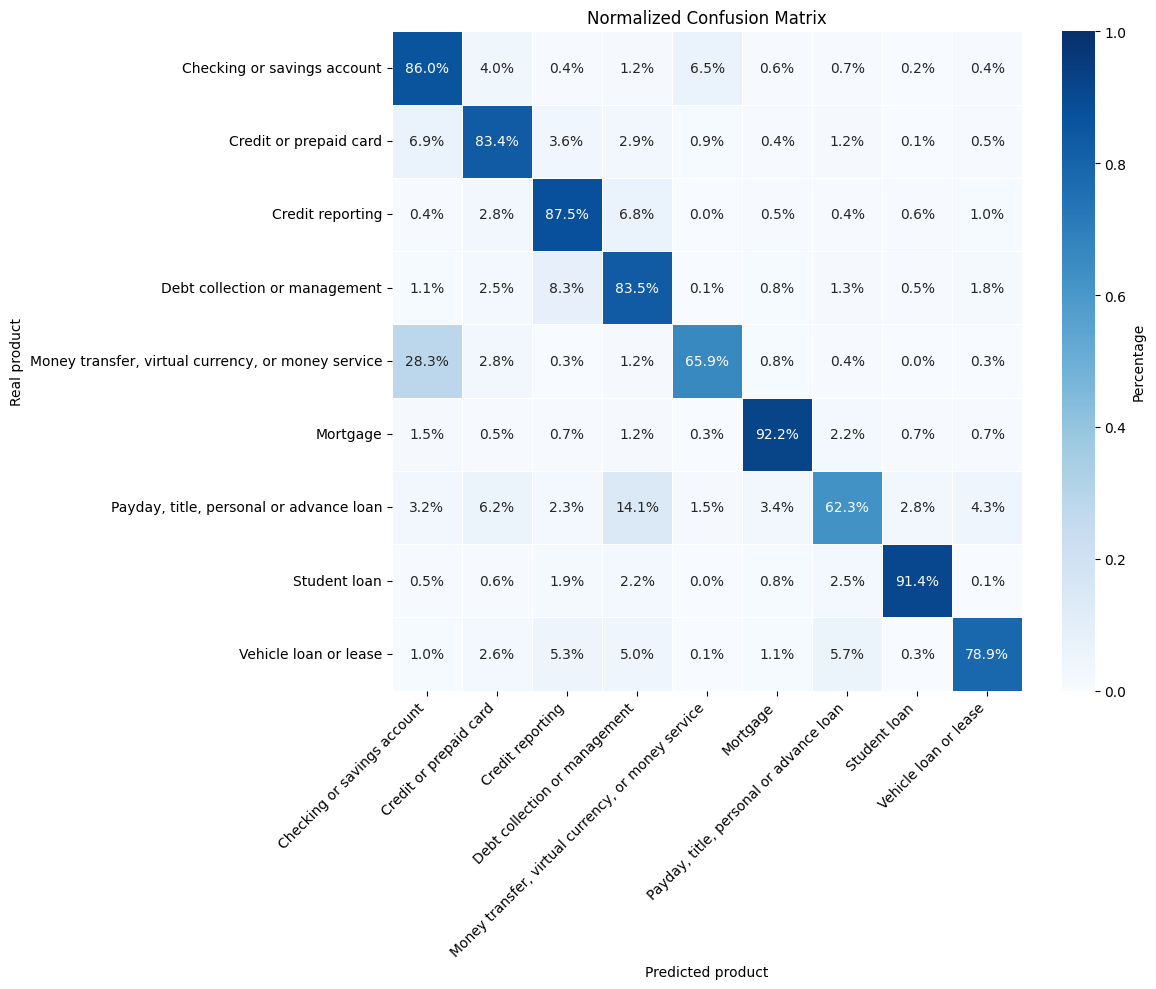

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

sns.heatmap(
    confusion_percentage,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    linewidths=0.5,
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Percentage"}
)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted product")
plt.ylabel("Real product")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

### Principales patrones de confusión

La diagonal concentra la mayor proporción de casos en todas las categorías, lo que confirma que el modelo distingue correctamente la mayor parte de los productos.

Las confusiones más relevantes son:

- El 28,3 % de las reclamaciones reales de `Money transfer...` se clasifica como `Checking or savings account`.
- El 14,1 % de las reclamaciones de `Payday...` se clasifica como `Debt collection or management`.
- Parte de las reclamaciones de `Debt collection or management` se asigna a `Credit reporting`.
- En `Vehicle loan or lease` aparecen confusiones con `Credit reporting` y `Debt collection or management`.
- También existe cierta confusión entre `Credit or prepaid card` y `Checking or savings account`.

Estos errores son coherentes con narrativas que mencionan varios momentos del mismo problema: el producto original, un impago, el proceso de recobro y su posterior aparición en el historial crediticio.

# PASO 19. Revisar algunos errores

Ver directamente las quejas incorrectas ayuda a entender si el problema está en el modelo o en la propia ambigüedad de las categorías.

In [ ]:
bert_errors = test_results_bert[
    ~test_results_bert["correct_without_threshold"]
][
    [
        FAMILY_LABEL_COL,
        "bert_prediction",
        "bert_confidence",
        TEXT_COL
    ]
].copy()

print("Número de errores sin threshold:", len(bert_errors))

display(
    bert_errors.head(20)
)

Número de errores sin threshold: 7965


,Product_family,bert_prediction,bert_confidence,Consumer complaint narrative
9,"Money transfer, virtual currency, or money service",Checking or savings account,0.543292,"I had a problem paying my car payment on the Chime app. and I wasnt able to do so. I called a number that said it was Chime. The person answered said welcome to Chime and gave me instructions to send money to the manager and he would update my account. However he used the words my manager will update you account. I didnt realize what was happening, what I was actually doing. I sent the update to a chime Id. I called back and they kept hanging up on me when I requested my money. I then went back to the internet. I saw that the number I called was from a sponsor and it said chime but it wasnt Chime. I called Chime they said I couldnt file a dispute because I authorized the transaction. Later I called Chime again. They allowed me to put the dispute through and denied my dispute. Chime would not allow me to report this transaction to the Chime fraud department. This was fraud. Someone posed as a chime employee tricked me out of my money. I looked for the fraudulent number on the Internet again and it was no where to be found. The number was gone as was the sponsers name. Also the only number thats showing on the Internet is the correct number for Chime everything else has disappeared! I would like help with this matter. \nXXXX XXXX"
13,Credit reporting,Debt collection or management,0.661367,Chase is still reporting an unlawfully debt thats has been past the statute of limitations of 7ywars federally and state level its three years.
16,Debt collection or management,Checking or savings account,0.499803,"On XX/XX/XXXX, I began my job at XXXX XXXX XXXX as the Excellence in Banking Director. I left my job as Chairman, President and CEO of the XXXX XXXX XXXX XXXX, Texas region. I lived at XXXX XXXX XXXX in XXXX and had a XXXX XXXX XXXX that was installed in XXXX. XXXX XXXX XXXX my successor bought my home and we called XXXX and they agreed to transfer the billing to him as he would keep the equipment. We did exactly as instructed and he is still with XXXX today. In XX/XX/XXXX, a collection was filed in the amount of {$550.00} with the credit bureau 's by Zions Debt Holdings, who received the collection from XXXX, who received the collection from XXXX. XXXX never closed out my account even though they made the transfer to XXXX XXXX XXXX. XXXX has never missed receiving payment for their service at XXXXXXXX XXXX since XXXX. I have spent over 3 hours only to be run in circles even though XXXX acknowledges the debt is not owed. My credit score has dropped from my perfect XXXX to around XXXX and I could let this roll off in a couple of years, but their behavior is wrong, both morally and in my opinion legally. Given this experience and their response to me trying to do the right thing, I believe you will find countless other people that XXXX is trying to fraudulently collect money from. I look forward to visiting with anyone about this manner. \nTake care. \nXXXX"
18,Credit reporting,Credit or prepaid card,0.786866,"I urgently request the removal of this erroneous late payment from my account. My consistent history of punctual payments contradicts this entry, causing me undue stress and concern. I ask that you promptly rectify this mistake by updating my account."
33,Debt collection or management,Credit reporting,0.962909,"I am writing to express my dismay and frustration regarding your response to my request for the blocking of certain information on my Equifax credit file, as outlined in your communication dated XXXX XXXX XXXX I received your notification stating that Equifax is not blocking the information I specified in my request, in accordance with Section 605B ( c ) of the Fair Credit Reporting Act. Your response, which outlines the initiation of an investigation and contact with each company providing the disputed information, does not align with my explicit request 

### Volumen y naturaleza de los errores

El modelo comete 7.965 errores sobre 58.249 observaciones de test, equivalente aproximadamente al 13,7 %, en línea con la accuracy global obtenida.

La revisión de ejemplos muestra dos tipos principales de error:

1. Reclamaciones con señales de varias categorías, en las que el texto menciona simultáneamente el producto, el cobro de una deuda y su efecto sobre el historial crediticio.
2. Predicciones con baja confianza, que representan casos más ambiguos y que en producción podrían ser filtrados mediante el threshold.

También aparecen algunos errores con confianza elevada. Estos casos requieren una revisión específica, ya que podrían reflejar etiquetas ruidosas, textos incompletos o patrones aprendidos incorrectamente por el modelo.

# PASO 20. Crear un pipeline para clasificar textos nuevos

Un pipeline simplifica la inferencia. Le pasamos una queja y devuelve la categoría predicha junto con una puntuación de confianza.

Una vez tengamos el modelo finetuneado y guardado, podemos crear este pipeline en producción para nuevas quejas.

Mostramos un ejemplo de cómo funcionaría a continuación.

In [ ]:
bert_classifier = pipeline(
    task="text-classification",
    model=trainer.model,
    tokenizer=tokenizer,

    # 0 significa la primera GPU.
    # -1 significaría CPU.
    device=0 if torch.cuda.is_available() else -1,

    truncation=True,
    max_length=MAX_LENGTH
)

In [ ]:
example_complaint = """
Experian continues to report an account that does not belong
to me even though I have disputed the information several times.
"""


prediction = bert_classifier(
    example_complaint
)

prediction

[{'label': 'Credit reporting', 'score': 0.9249163866043091}]

### Ejemplo de inferencia

El pipeline clasifica correctamente el ejemplo como `Credit reporting` con una confianza del 92,49 %.

Este objeto permite reutilizar el modelo entrenado para clasificar nuevas reclamaciones sin repetir el proceso de entrenamiento, devolviendo directamente la categoría y su nivel de confianza.

# Conclusión final

El fine-tuning de SEC-BERT proporciona un prototipo sólido para clasificar reclamaciones financieras en nueve familias de producto.

Sobre el conjunto de test original, el modelo obtiene una accuracy del 86,33 %, un weighted F1 del 87,20 % y un macro F1 del 73,42 %. El balanceo aplicado en train permite alcanzar un recall macro del 81,24 %, aunque a costa de una menor precision en algunas categorías minoritarias.

La incorporación de un threshold de confianza de 0,70 permite automatizar el 85,77 % de las reclamaciones con una accuracy del 91,54 % y un macro F1 del 82,67 %. El 14,23 % restante podría enviarse a revisión manual o a una segunda etapa de clasificación.

Los mejores resultados se obtienen en `Credit reporting` y `Mortgage`, mientras que `Payday, title, personal or advance loan` y `Vehicle loan or lease` continúan siendo las categorías más difíciles. Las principales confusiones se producen entre productos relacionados con cuentas, deuda, crédito y reporting, especialmente cuando una misma reclamación describe varias fases del problema.

El entrenamiento se ha limitado a una época y a una longitud máxima de 128 tokens por restricciones de GPU. Con mayor capacidad de cómputo sería recomendable evaluar más épocas, longitudes superiores y early stopping, monitorizando las curvas de training y validation loss. Por tanto, los resultados deben interpretarse como los de un prototipo funcional y no como el máximo rendimiento alcanzable.